# Introducción.

El objetivo es predecir la popularidad de canciones en Spotify utilizando características acústicas y de género comparando modelos lineales y métodos de boosting.

Cargamos las paqueterias que estaremos utilizando.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
import shap

from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

plt.style.use('ggplot')

# Carga y limpeza de los datos.

Bueno, comencemos caragando los datos.

In [86]:
df = pd.read_csv('/content/dataset.csv')

Quitemos de una los duplicados.

In [87]:
df = (
    df
    .drop_duplicates(
        subset='track_id'
    )
    .reset_index(drop=True)
)

Echemos un vistazo para ver que hay en el dataset.

In [8]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Veamos ahora las dimensiones del dataset.

In [9]:
df.shape

(89741, 21)

Vamos a checar un poco mejor las columnas, para darnos una idea de las variables con las que contamos.

In [10]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

Ok, ya vimos las columnas, de hecho ya las habimamos visto cuando vimos el dataset. Veamos un poco mas de info, no esta de mas.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89741 entries, 0 to 89740
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        89741 non-null  int64  
 1   track_id          89741 non-null  object 
 2   artists           89740 non-null  object 
 3   album_name        89740 non-null  object 
 4   track_name        89740 non-null  object 
 5   popularity        89741 non-null  int64  
 6   duration_ms       89741 non-null  int64  
 7   explicit          89741 non-null  bool   
 8   danceability      89741 non-null  float64
 9   energy            89741 non-null  float64
 10  key               89741 non-null  int64  
 11  loudness          89741 non-null  float64
 12  mode              89741 non-null  int64  
 13  speechiness       89741 non-null  float64
 14  acousticness      89741 non-null  float64
 15  instrumentalness  89741 non-null  float64
 16  liveness          89741 non-null  float6

Eliminemos las columnas que no nos sirven

In [12]:
df.drop(
    columns=['Unnamed: 0', 'Unnamed: 0.1'],
    inplace=True,
    errors='ignore'
)

Chequemos los nulos

In [13]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


Su porcentaje

In [14]:
(df.isnull().mean()*100)\
.sort_values(ascending=False)

,0
artists,0.001114
album_name,0.001114
track_name,0.001114
track_id,0.000000
popularity,0.000000
duration_ms,0.000000
explicit,0.000000
danceability,0.000000
energy,0.000000
key,0.000000


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['track_id'].duplicated().sum()

np.int64(0)

# Análisis exploratorio.

Toca checar la variable objetivo popularity, veamos un resumen.



In [17]:
df['popularity'].describe()

,popularity
count,89741.000000
mean,33.198438
std,20.580824
min,0.000000
25%,19.000000
50%,33.000000
75%,49.000000
max,100.000000


Ahora los percentiles para checar la distribucion de las canciones

In [18]:
df['popularity'].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,popularity
count,89741.000000
mean,33.198438
std,20.580824
min,0.000000
10%,0.000000
25%,19.000000
50%,33.000000
75%,49.000000
90%,60.000000
95%,67.000000


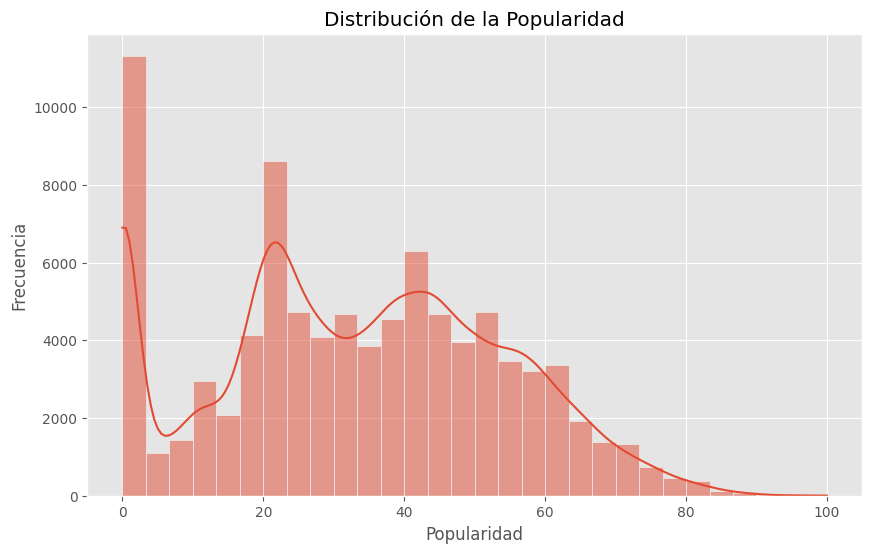

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['popularity'],
    bins=30,
    kde=True
)

plt.title('Distribución de la Popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')

plt.show()

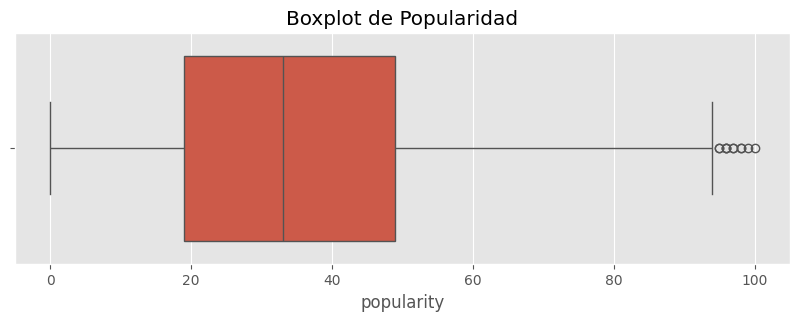

In [20]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df['popularity']
)

plt.title('Boxplot de Popularidad')

plt.show()

In [21]:
df['popularity'].value_counts().sort_index()

,count
popularity,
0,9448
1,1085
2,495
3,301
4,231
...,...
96,3
97,2
98,2


La variable objetivo presenta una distribución asimétrica y una concentración considerable de canciones con popularidad nula, entonces seria bueno comparar funciones de pérdida basadas en Error Cuadrático Medio (MSE) y Error Absoluto Medio (MAE) ya que MAE suele ser más robusto frente a las distribuciones no normales

Pero bueno, mientras demosle un vistazo a los gnéneros musicales

In [22]:
df['track_genre'].nunique()

113

In [23]:
df['track_genre'].value_counts()

,count
track_genre,
acoustic,1000
afrobeat,999
alt-rock,999
ambient,999
cantopop,999
...,...
metal,232
punk,226
house,210


In [88]:
top_genres = (
    df['track_genre']
    .value_counts()
    .head(15)
)

top_genres

,count
track_genre,
acoustic,1000
afrobeat,999
alt-rock,999
ambient,999
cantopop,999
tango,999
chicago-house,998
forro,998
bluegrass,998


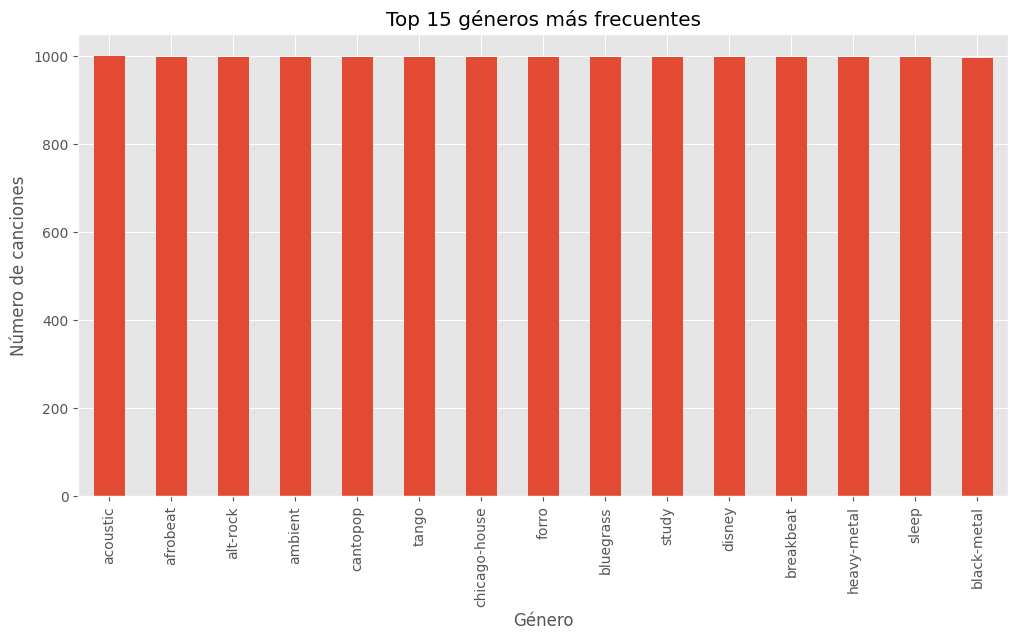

In [89]:
plt.figure(figsize=(12,6))

top_genres.plot(
    kind='bar'
)

plt.title(
    'Top 15 géneros más frecuentes'
)

plt.xlabel('Género')
plt.ylabel('Número de canciones')

plt.show()

In [90]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
)

genre_popularity.head(15)

,popularity
track_genre,
k-pop,59.358779
pop-film,59.096933
metal,56.422414
chill,53.738683
latino,51.788945
sad,51.109929
grunge,50.587007
indian,49.765348
anime,48.776884


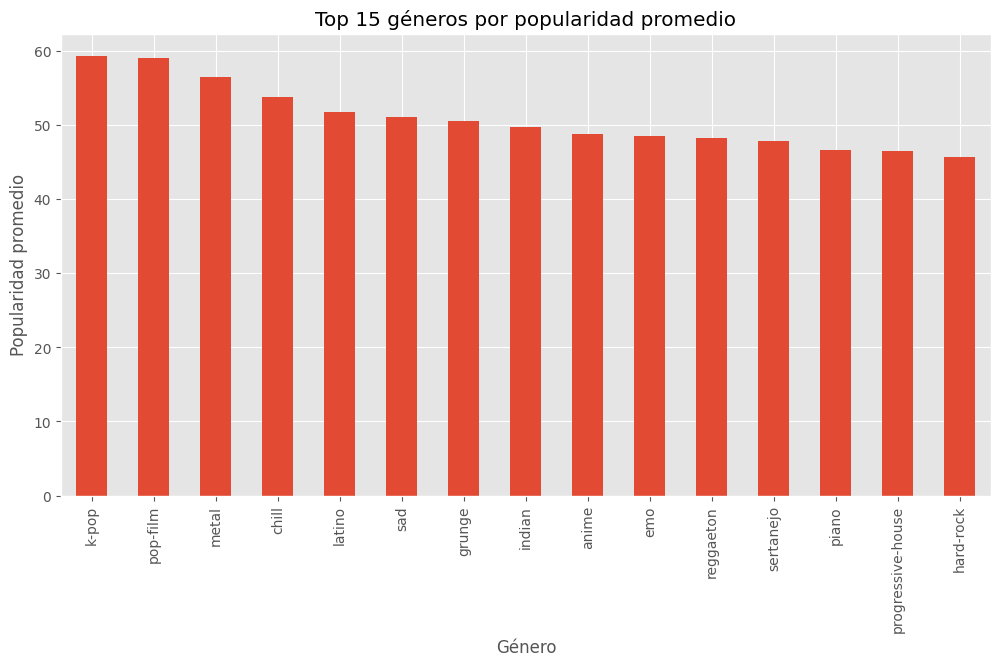

In [28]:
plt.figure(figsize=(12,6))

genre_popularity.head(15).plot(
    kind='bar'
)

plt.title(
    'Top 15 géneros por popularidad promedio'
)

plt.xlabel('Género')
plt.ylabel('Popularidad promedio')

plt.show()

In [91]:
genre_popularity.tail(15)

,popularity
track_genre,
breakbeat,20.171515
tango,19.866867
rock,18.178363
country,17.345666
honky-tonk,16.410805
idm,15.522222
kids,14.770791
grindcore,14.521827
classical,13.362168


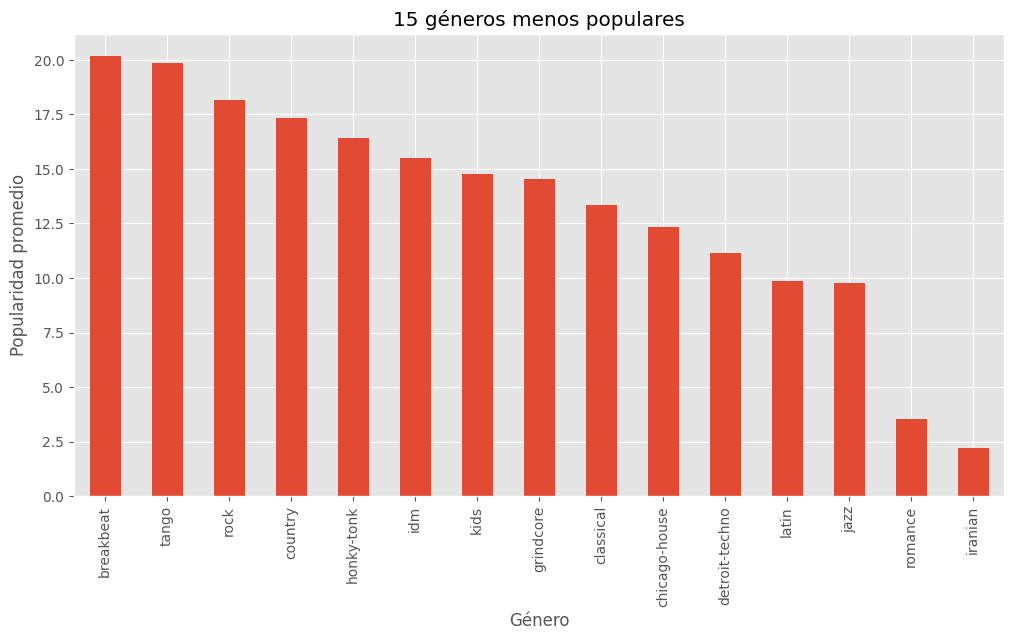

In [92]:
plt.figure(figsize=(12,6))

genre_popularity.tail(15).plot(
    kind='bar'
)

plt.title(
    '15 géneros menos populares'
)

plt.xlabel('Género')
plt.ylabel('Popularidad promedio')

plt.show()

In [98]:
top15_popular = genre_popularity.head(15).index

df_top = df[
    df['track_genre'].isin(top15_popular)
]

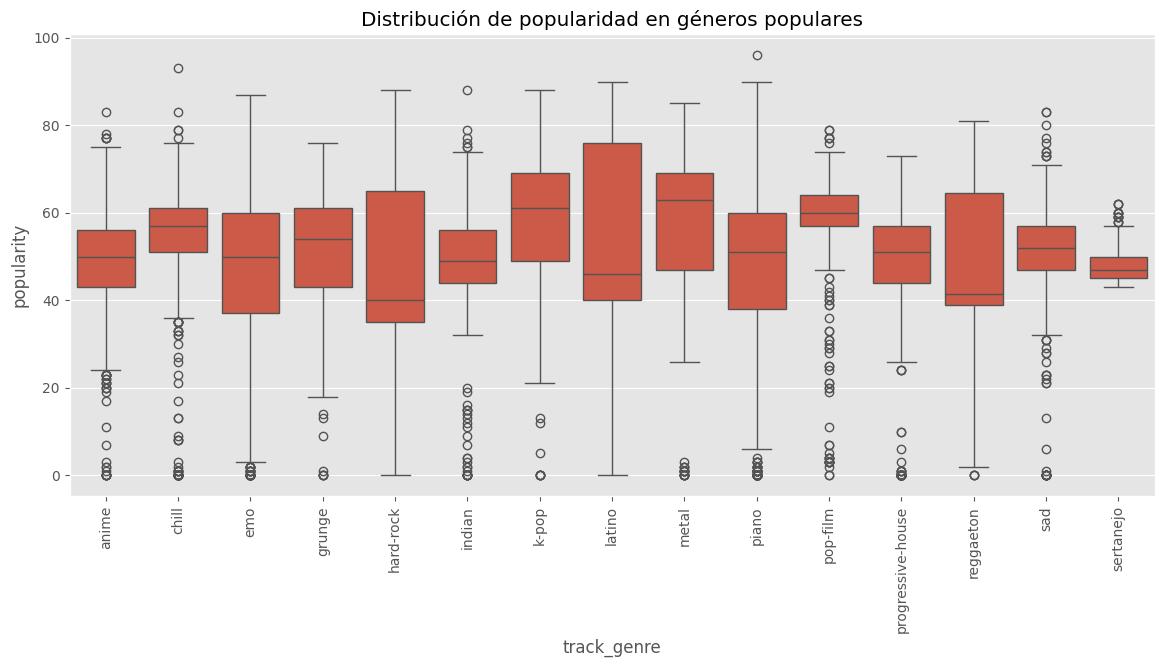

In [99]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_top,
    x='track_genre',
    y='popularity'
)

plt.xticks(rotation=90)

plt.title(
    'Distribución de popularidad en géneros populares'
)

plt.show()

 La mayoría de los géneros cuentan con una representación similar dentro del dataeet con aproximadamente 1000 canciones por categoría, pero luego del proceso de limpeiza, algunos géneros como reggaetón, indie, house, etc presentan una menor cantidad de observaciones. El K-Pop, Pop Film, Metal, Chill y Latino presentan los niveles de popularidad promedio más altos mientras que Iranian, Romance, Jazz y Detroit Techno muestran valores menores.

Esto sugiere que la popularidad de una canción no depende únicamente de sus características acústicas, sino también del género musical.

In [100]:
audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

In [101]:
corr = df[
    audio_features +
    ['popularity']
].corr()

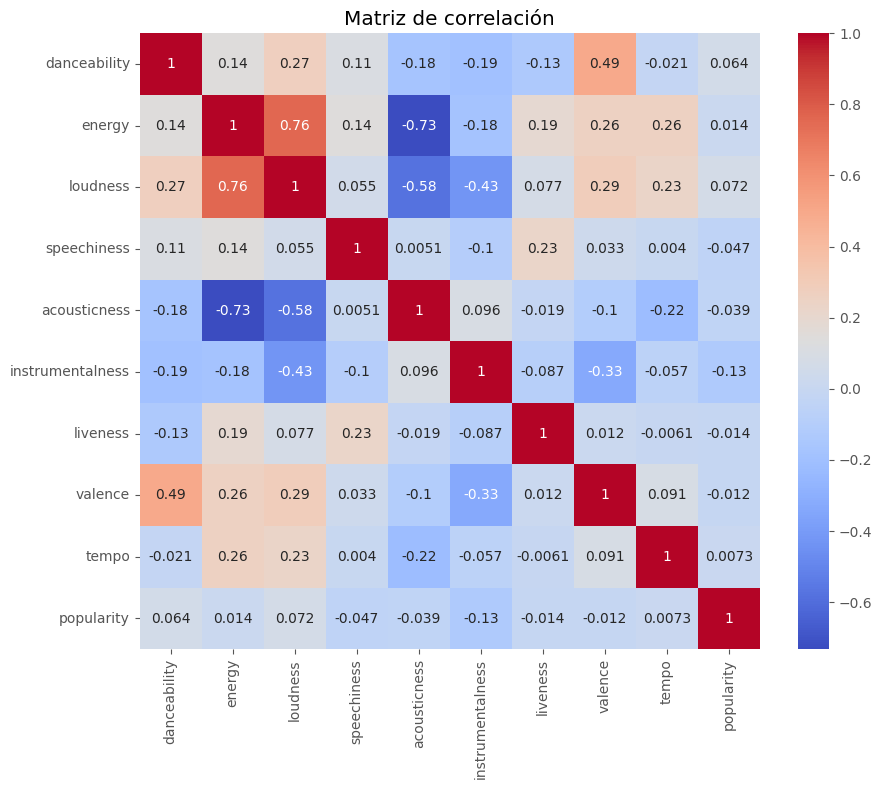

In [102]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Matriz de correlación'
)

plt.show()

In [103]:
corr['popularity']\
.sort_values(
    ascending=False
)

,popularity
popularity,1.000000
loudness,0.071676
danceability,0.064281
energy,0.013728
tempo,0.007270
valence,-0.011526
liveness,-0.013844
acousticness,-0.038847
speechiness,-0.047081
instrumentalness,-0.127465


In [38]:
from scipy.stats import spearmanr

In [39]:
spearman_results = {}

for col in audio_features:

    coef,_ = spearmanr(
        df[col],
        df['popularity']
    )

    spearman_results[col] = coef

pd.Series(
    spearman_results
).sort_values(
    ascending=False
)

,0
loudness,0.067249
danceability,0.055303
acousticness,0.010231
tempo,0.008312
valence,-0.010704
liveness,-0.011448
energy,-0.015737
speechiness,-0.067056
instrumentalness,-0.124414


In [40]:
pd.DataFrame({
    'Spearman':
    pd.Series(
        spearman_results
    )
}).sort_values(
    'Spearman',
    ascending=False
)

,Spearman
loudness,0.067249
danceability,0.055303
acousticness,0.010231
tempo,0.008312
valence,-0.010704
liveness,-0.011448
energy,-0.015737
speechiness,-0.067056
instrumentalness,-0.124414


In [104]:
sample_df = df.sample(
    10000,
    random_state=42
)

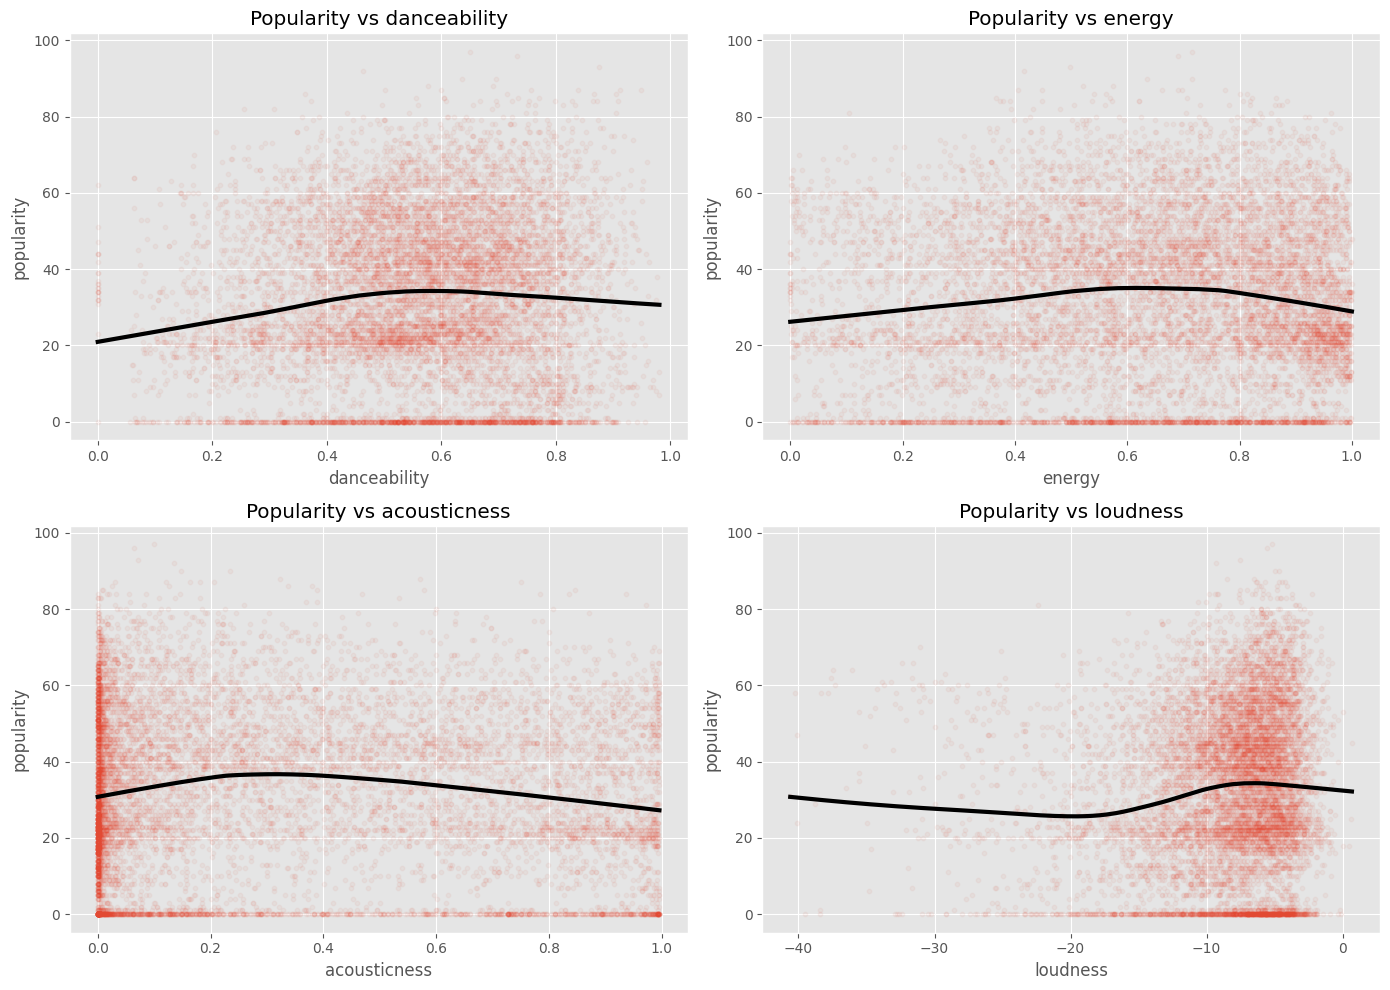

In [105]:
sample_df = df.sample(
    10000,
    random_state=42
)

variables = [
    'danceability',
    'energy',
    'acousticness',
    'loudness'
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

for ax, var in zip(axes.flatten(), variables):

    sns.regplot(
        data=sample_df,
        x=var,
        y='popularity',
        lowess=True,
        ax=ax,
        scatter_kws={
            'alpha':0.05,
            's':10
        },
        line_kws={
            'color':'black',
            'linewidth':3
        }
    )

    ax.set_title(
        f'Popularity vs {var}'
    )

plt.tight_layout()

plt.show()

Las correlaciones de Pearson y Spearman mostraron asociaciones débiles entre las características acústicas individuales y la popularidad de las canciones, no se observa alguna relación lineal,por lo que seria bueno evaluar modelos más flexibles como Random Forest, AdaBoost, XGBoost y redes neuronales MLP.

# Implementación de modelos lineales



Vamos a entrenar modelos lineales y see comparan regresión lineal, Ridge, Lasso y Elastic Net.

In [106]:

df_model = df.copy()
df_model = df_model.drop(
    columns=[
        'track_id',
        'track_name',
        'album_name',
        'artists'
    ]
)
df_model['explicit'] = df_model['explicit'].astype(int)
df_model['key'] = df_model['key'].astype(str)

In [107]:
X = df_model.drop(
    columns='popularity'
)

y = df_model['popularity']

print(X.shape)
print(y.shape)

(89741, 16)
(89741,)


In [108]:
num_features = [
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

cat_features = [
    'key',
    'track_genre'
]

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

In [111]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

In [112]:
results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('MAE')

results_df

,Model,MAE,RMSE,R2
2,Lasso,12.218977,16.874437,0.318283
0,Linear Regression,12.476537,17.180979,0.293290
3,ElasticNet,13.286687,17.348450,0.279446
1,Ridge,16.425380,20.024552,0.040001


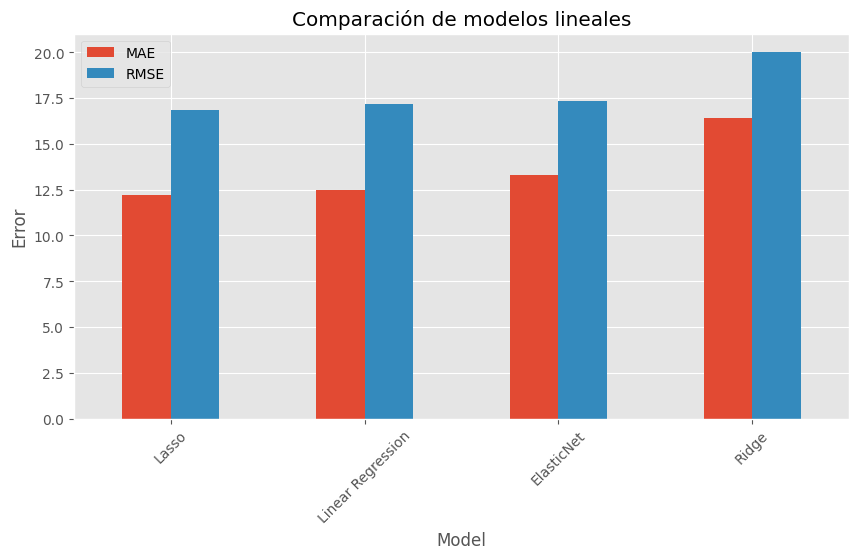

In [113]:
results_df.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Comparación de modelos lineales')
plt.ylabel('Error')
plt.xticks(rotation=45)
plt.show()

Lasso presentó el mejor desempeño entre los modelos lineales, seguido de la regresión y Elastic.

# Modelos de ensamble basados en árboles.

Los modelos lineales alcanzaron un R² de casi 0.32 lo que tal vez la popularidad no puede explicarse con esos modelos. Intentemos con Random Forest y Ada Boost

In [114]:
rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model',
         RandomForestRegressor(
             n_estimators=100,
             max_depth=20,
             min_samples_leaf=2,
             random_state=42,
             n_jobs=-1
         ))
    ]
)

In [115]:
rf.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['duration_ms',
                                                   'danceability', 'energy',
                                                   'loudness', 'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['key', 'track_genre'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_jobs=-1, random_state=42))])

In [116]:
rf_preds = rf.predict(
    X_test
)

In [117]:
rf_mae = mean_absolute_error(
    y_test,
    rf_preds
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_preds
    )
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 13.205634704460131
RMSE: 17.39623957072111
R²  : 0.27547064471521354


Salió peor Random Forest con un R² de casi 0.28.

Intenemos con Ada Boost a ver si de casualidad mejora.

In [118]:
ada = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model',
         AdaBoostRegressor(
             estimator=DecisionTreeRegressor(
                 max_depth=4
             ),
             n_estimators=300,
             learning_rate=0.05,
             random_state=42
         ))
    ]
)

In [119]:
ada.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['duration_ms',
                                                   'danceability', 'energy',
                                                   'loudness', 'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['key', 'track_genre'])])),
                ('model',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                                   learning_rate=0.05, n_estimators=300,
                                   random_state=42))])

In [120]:
ada_preds = ada.predict(
    X_test
)

ada_mae = mean_absolute_error(
    y_test,
    ada_preds
)

ada_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ada_preds
    )
)

ada_r2 = r2_score(
    y_test,
    ada_preds
)

print("MAE :", ada_mae)
print("RMSE:", ada_rmse)
print("R²  :", ada_r2)

MAE : 16.715878696361454
RMSE: 20.00149502095081
R²  : 0.04221034211431074


Terrible resultado. De momento hemos intentado  con modelos lineales y de ensamble, pero por los resultados podemos pensar quela relación entre las características acusticas y la popularidad es compleja y posiblemente no lineal.



# XGBoost

XGBoost es un algoritmo de Gradient Boosting que construye árboles de decisión de manera secuencial corrigiendo iterativamente los errores de los árboles anteriores.

In [121]:
xgb_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model',
         XGBRegressor(
             objective='reg:squarederror',
             n_estimators=500,
             max_depth=6,
             learning_rate=0.05,
             subsample=0.8,
             colsample_bytree=0.8,
             random_state=42,
             n_jobs=-1
         ))
    ]
)

In [122]:
xgb_pipe.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['duration_ms',
                                                   'danceability', 'energy',
                                                   'loudness', 'speechiness',
                                                   'acousticness',
                                                   'instrumentalness',
                                                   'liveness', 'valence',
                                                   'tempo']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['key', 'track_genre'])])),
                ('model',
                 XGBRegressor(base_score=None...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [123]:
xgb_preds = xgb_pipe.predict(
    X_test
)

In [124]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_preds
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_preds
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

MAE : 10.634562492370605
RMSE: 15.222686321178921
R²  : 0.4452110528945923


In [ ]:
Bingo, el mejor hasta ahorita y el ganador de momento.

In [125]:
comparison = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Ridge',
        'Lasso',
        'ElasticNet',
        'Random Forest',
        'AdaBoost',
        'XGBoost'
    ],

    'MAE':[
        12.008310,
        12.011316,
        12.215120,
        13.298938,
        rf_mae,
        ada_mae,
        xgb_mae
    ],

    'R2':[
        0.320771,
        0.320786,
        0.318357,
        0.279169,
        rf_r2,
        ada_r2,
        xgb_r2
    ]
})

comparison.sort_values(
    'R2',
    ascending=False
)

,Model,MAE,R2
6,XGBoost,10.634562,0.445211
1,Ridge,12.011316,0.320786
0,Linear Regression,12.008310,0.320771
2,Lasso,12.215120,0.318357
3,ElasticNet,13.298938,0.279169
4,Random Forest,13.205635,0.275471
5,AdaBoost,16.715879,0.042210


XGBoost obtuvo el mejor desempeño entre todos los modelos evaluados alcanzando un R² de 0.445 y el menor MAE, seguido de Ridge y la Regresión.

# Variables importantes.

In [126]:
feature_names = (
    xgb_pipe
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [127]:
importances = (
    xgb_pipe
    .named_steps['model']
    .feature_importances_
)

In [128]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

importance_df.head(20)

,Feature,Importance
81,cat__track_genre_iranian,0.058873
115,cat__track_genre_romance,0.050873
87,cat__track_genre_k-pop,0.037253
103,cat__track_genre_pop-film,0.033686
37,cat__track_genre_chill,0.028353
35,cat__track_genre_chicago-house,0.027233
46,cat__track_genre_detroit-techno,0.026708
74,cat__track_genre_honky-tonk,0.025199
89,cat__track_genre_latin,0.024688
88,cat__track_genre_kids,0.023341


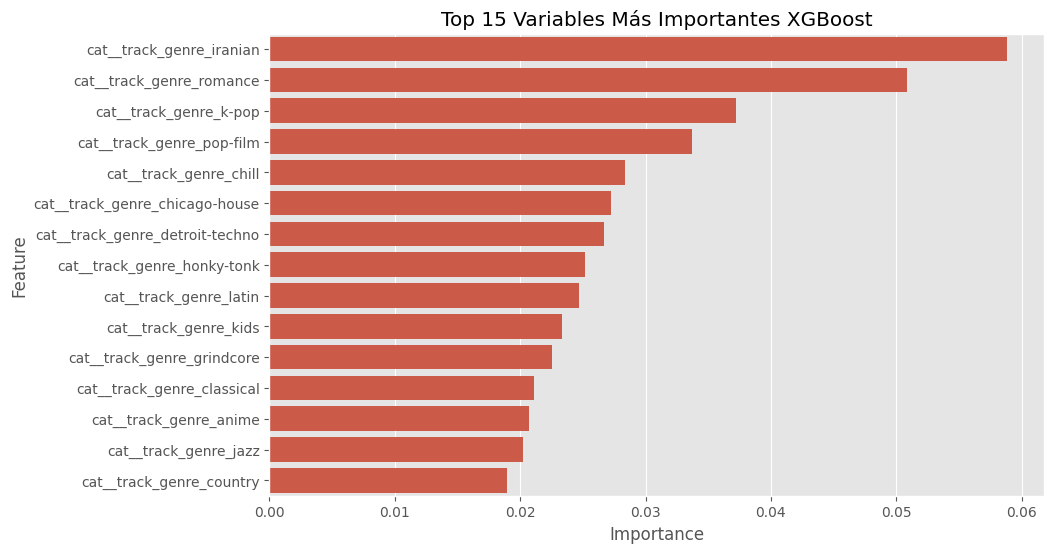

In [129]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Variables Más Importantes XGBoost'
)

plt.show()



Este análsisi muestra que los geneeros musicales son importantes  para XGboost, las variables mas importantes corresponden principalmente a la categoria `track_genre` mientras que las características acusticas individuales tienen un peso menor.


